In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
import joblib
from sklearn.model_selection import train_test_split
from collections import Counter

In [2]:
df = pd.read_csv("emails_raw.csv")

# 1. Check data file
print("===== Head =====")
print(df.head()) #xem vài dòng đầu của dataset

print("\n==== Columns =====")
print(df.columns)

print("\n====== Info ======")
df.info()

===== Head =====
                                                text  spam
0  Subject: naturally irresistible your corporate...     1
1  Subject: the stock trading gunslinger  fanny i...     1
2  Subject: unbelievable new homes made easy  im ...     1
3  Subject: 4 color printing special  request add...     1
4  Subject: do not have money , get software cds ...     1

==== Columns =====
Index(['text', 'spam'], dtype='str')

====== Info ======
<class 'pandas.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    5728 non-null   str  
 1   spam    5728 non-null   int64
dtypes: int64(1), str(1)
memory usage: 89.6 KB


In [3]:
# 2. Remove missing data & duplicate emails
# Check missing data
print("===== Missing Data =====")
print(df.isnull().sum())
if df.isnull().values.any():
    df = df.dropna() #dùng để xoá dòng bị thiếu data

# Check duplicate emails
print("\n===== Duplicate emails =====")
print("Shape before:", df.shape)

print("Duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

===== Missing Data =====
text    0
spam    0
dtype: int64

===== Duplicate emails =====
Shape before: (5728, 2)
Duplicate rows: 33
Shape after removing duplicates: (5695, 2)


In [4]:
# 3. Check label có cân bằng không (vì nếu quá lệch nhau => accuracy bị ảnh hưởng)
# Độ lệch 70:30 đến 85:15 là đẹp
counts = df["spam"].value_counts()

percent = df["spam"].value_counts(
    normalize=True
) * 100

print("Counts:")
print(counts)

print("\nPercentages:")
for label, p in percent.items():
    print(f"Class {label}: {p:.2f}%")

Counts:
spam
0    4327
1    1368
Name: count, dtype: int64

Percentages:
Class 0: 75.98%
Class 1: 24.02%


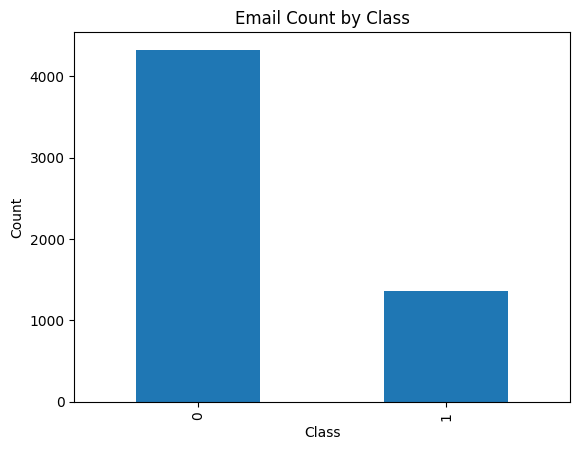

In [ ]:
# Bar char Email COunt by Class
counts = df["spam"].value_counts()

counts.plot(
    kind="bar"
)

plt.title("Email Count by Class")

plt.xlabel("Class")

plt.ylabel("Count")

plt.show()

In [ ]:
# 4. Text cleaning
def clean(text):
    # Chuyển toàn bộ thành chữ thường
    text = text.lower()
    # Remove email reply prefixes (tiền tố)
    text = re.sub(
        r'((re|fw|fwd)\s*:)+',
        ' ',
        text
    )

    # remove "subject:"
    text = re.sub(
        r'subject\s*:',
        ' ',
        text
    )
    # Xoá URL
    text = re.sub(r'http\S+|www\S+',' ',text)
    # Xóa HTML tags
    text = re.sub(r'<.*?>',' ',text)
    # Xoá mọi thứ KHÔNG phải chữ cái
    text = re.sub(r'[^a-zA-Z ]',' ',text)
    # Dọn khoảng trắng thừa
    text = re.sub(r'\s+',' ',text).strip()

    return text

df["text"] = df["text"].apply(clean)
df.to_csv("emails_cleaned.csv", index=False)

# remove blank emails after cleaning
df = df[df["text"].str.strip() != ""]

# remove duplicates after cleaning
df = df.drop_duplicates(subset=["text"])

# Check
print("Blank rows:",
      (df["text"] == "").sum())

print("Duplicate texts:",
      df["text"].duplicated().sum())
df.to_csv("emails_cleaned.csv", index=False)

Blank rows: 0
Duplicate texts: 0


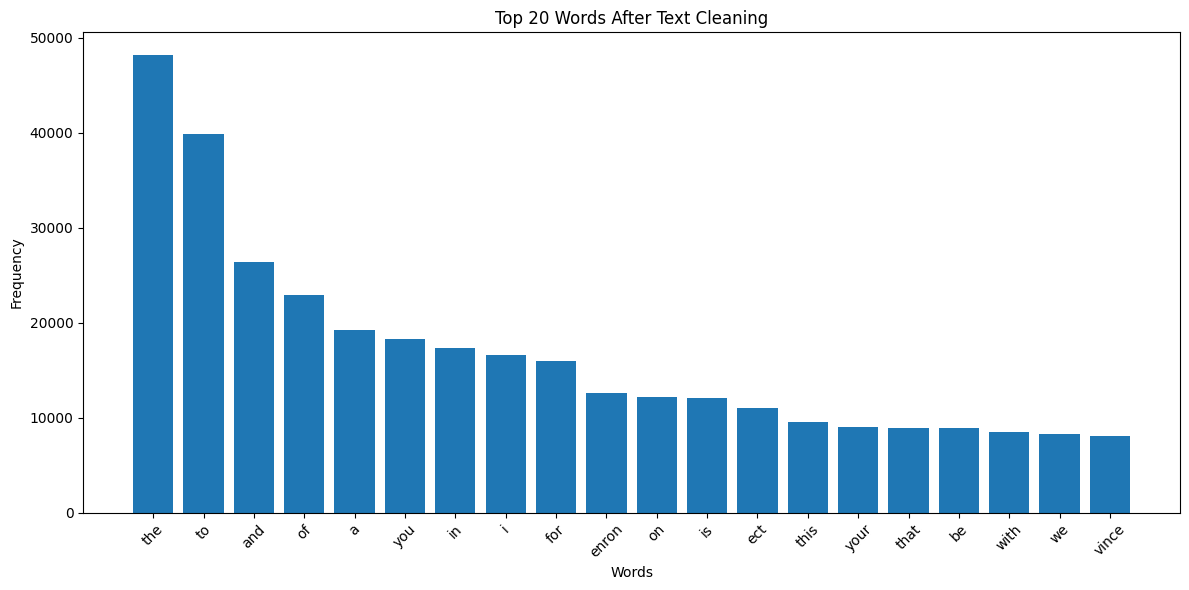

In [ ]:
# Top 20 từ xuất hiện nhiều nhất sau khi cleaning


# Gộp toàn bộ email thành một chuỗi
all_words = " ".join(df["text"])

# Tách thành danh sách từ
words = all_words.split()

# Đếm số lần xuất hiện
word_counts = Counter(words)

# Lấy top 20
top_words = word_counts.most_common(20)

labels = [word for word, count in top_words]
values = [count for word, count in top_words]

plt.figure(figsize=(12,6))
plt.bar(labels, values)

plt.title("Top 20 Words After Text Cleaning")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Basic Statistics
df["email_length"] = df["text"].str.len()
print("===== Email Length Statistics =====")
print(df["email_length"].describe())

# Compare average email length by class
print("\n===== Mean Email Length By Class =====")

print(
    df.groupby("spam")
      ["email_length"]
      .mean()
)

===== Email Length Statistics =====
count     5695.000000
mean      1558.067076
std       2047.078711
min         13.000000
25%        508.500000
50%        979.000000
75%       1893.000000
max      43952.000000
Name: email_length, dtype: float64

===== Mean Email Length By Class =====
spam
0    1634.200139
1    1317.257310
Name: email_length, dtype: float64
Longest email length: 43952


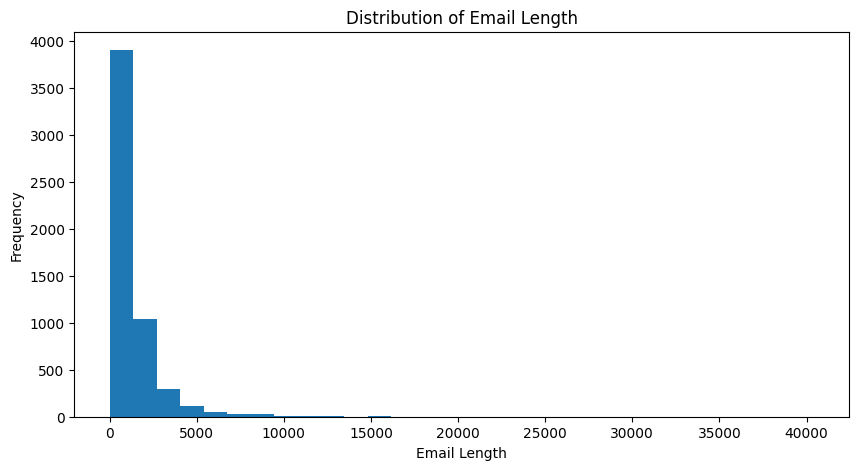

In [ ]:
# Distribution Plot (Histogram): thể hiện phân bố độ dài email cho cả dataset
plt.figure(figsize=(10,5))

plt.hist(df["email_length"], bins=30)

plt.title("Distribution of Email Length")
plt.xlabel("Email Length")
plt.ylabel("Frequency")

plt.show()

In [ ]:
# Skewness
print(
    "Skewness:",
    df["email_length"].skew()
)

Skewness: 7.558972706219621


In [ ]:
# Group Statistic: riêng cho từng class spam/ham
print(
    df.groupby("spam")["email_length"]
      .describe()
)

       count         mean          std  min    25%    50%      75%      max
spam                                                                       
0     4130.0  1339.000969  1720.395520  3.0  461.0  893.0  1640.75  40439.0
1     1366.0  1130.436310  2026.810869  3.0  330.5  531.5  1048.00  24854.0


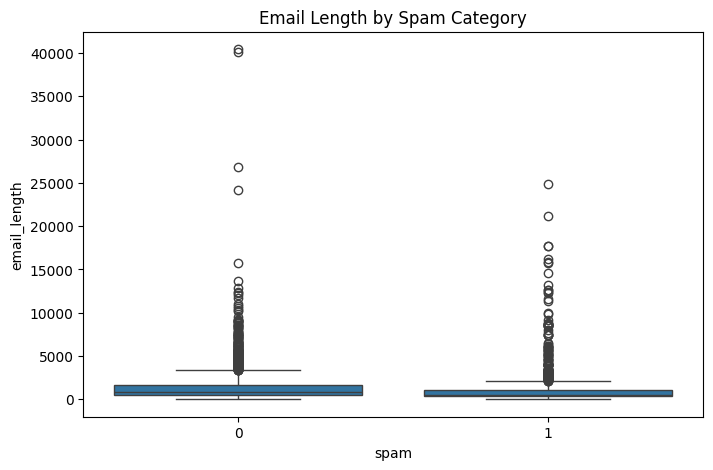

In [ ]:
# Boxplot
plt.figure(figsize=(8,5))

sns.boxplot(
    x="spam",
    y="email_length",
    data=df
)

plt.title(
    "Email Length by Spam Category"
)

plt.show()

In [ ]:
# Outlier Detection - IQR
Q1 = df["email_length"].quantile(0.25)

Q3 = df["email_length"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["email_length"] < lower_bound)
    |
    (df["email_length"] > upper_bound)
]

print("IQR Outliers:", len(outliers))



IQR Outliers: 397


In [17]:
# Outlier Detection - Z Score
mean = df["email_length"].mean()

std = df["email_length"].std()

z_scores = (df["email_length"] - mean) / std

outliers_z = (abs(z_scores) > 3).sum()

print("Z-score Outliers:", outliers_z)

Z-score Outliers: 89


In [ ]:
# 5. Chia train / test
X = df["text"]
y = df["spam"]

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42, #cố định cách chia
    stratify=y #cố định tỉ lệ spam/ham ở train và test giống tỉ lệ của dataset
)
print("Train samples:", len(X_train_text))
print("Test samples:", len(X_test_text))

# Lưu train / test chưa vector
train_df = pd.DataFrame({
    "text": X_train_text.values,   #.values để tránh mismatch index (tránh tạo dataframe với index lung tung)
    "spam": y_train.values
})

test_df = pd.DataFrame({
    "text": X_test_text.values,
    "spam": y_test.values
})

train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

Train samples: 4396
Test samples: 1100


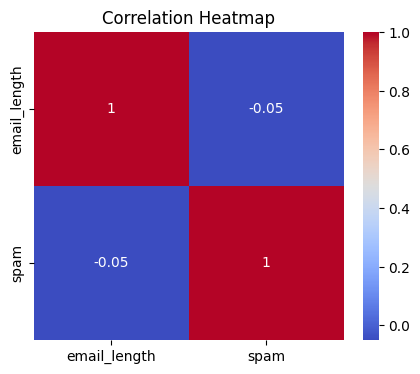

In [ ]:
# Heat map
corr = df[
    ["email_length", "spam"]
].corr()

plt.figure(figsize=(5,4))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [9]:
# Count unique words before vectorization

all_words = " ".join(
    df["text"]
).split()

unique_words = set(
    all_words
)

print("Total words:", len(all_words))

print("Unique words:", len(unique_words))

Total words: 1237069
Unique words: 33727


In [ ]:
# 6. Vectorize: Chuyển text → số (Vì ML ko hiểu chữ)

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    min_df=2, #document frequency: chỉ giữ từ xuất hiện ít nhất 2 emails
    ngram_range=(1,2),
    token_pattern=r'\b\w{4,}\b' #ít nhất 4 kí tự
)
X_train = vectorizer.fit_transform(X_train_text)

X_test = vectorizer.transform(X_test_text)
# in shape
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# Lưu vectorizer
joblib.dump(
    vectorizer,
    "tfidf_vectorizer.pkl"
)
print("Vectorizer saved!")

# lưu feature count để debug
print(
    "Vocabulary size:",
    len(vectorizer.vocabulary_)
)

# lưu data sau khi vectorize
joblib.dump(X_train, "X_train.pkl")
joblib.dump(X_test, "X_test.pkl")

joblib.dump(y_train, "y_train.pkl")
joblib.dump(y_test, "y_test.pkl")

Train shape: (4396, 10000)
Test shape: (1100, 10000)
Vectorizer saved!
Vocabulary size: 10000


['y_test.pkl']

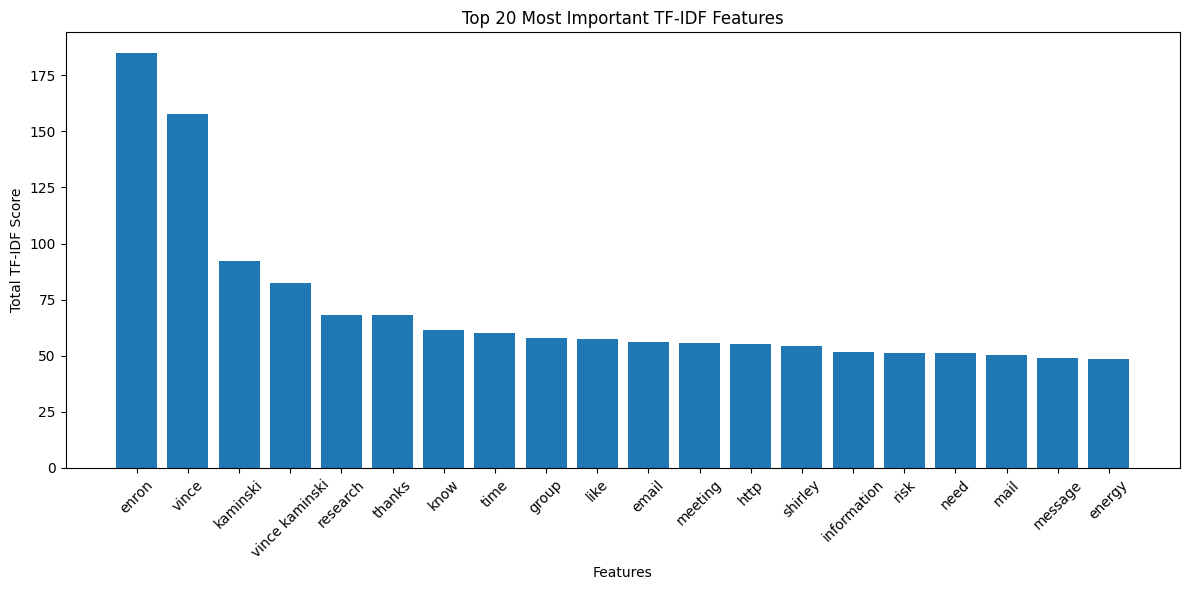

In [ ]:
# Top 20 features
scores = np.asarray(
    X_train.sum(axis=0)
).ravel()

features = vectorizer.get_feature_names_out()

top_idx = scores.argsort()[-20:][::-1]

top_features = features[top_idx]
top_scores = scores[top_idx]

plt.figure(figsize=(12,6))

plt.bar(top_features, top_scores)

plt.title("Top 20 Most Important TF-IDF Features")
plt.xlabel("Features")
plt.ylabel("Total TF-IDF Score")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()